#  Análise Exploratória de Dados (EDA): Goodreads Dataset

In [141]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))


# Importação de Bibliotecas e Módulos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Nossos módulos customizados da pasta src/
from src import load_data
from src import resumo_qualidade
from src import (
    estilizar_tabela,
    estilizar_resumo_qualidade,
    destacar_anomalias, 
    grafico_percentual_missing_data
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---

## Carregando Dados

In [142]:
caminho = '../data/raw/Goodreads_books_with_genres.csv'
df_books = load_data(file_path=caminho, tipo_arquivo='csv')

Dados CSV carregados! Formato: (11127, 13)


- - - 

## Exploração Inicial - Visão Geral

In [143]:
print("Estrutura do DataFrame:\n")
df_books.info()

Estrutura do DataFrame:

<class 'pandas.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Book Id             11127 non-null  int64  
 1   Title               11127 non-null  str    
 2   Author              11127 non-null  str    
 3   average_rating      11127 non-null  float64
 4   isbn                11127 non-null  str    
 5   isbn13              11127 non-null  int64  
 6   language_code       11127 non-null  str    
 7   num_pages           11127 non-null  int64  
 8   ratings_count       11127 non-null  int64  
 9   text_reviews_count  11127 non-null  int64  
 10  publication_date    11127 non-null  str    
 11  publisher           11127 non-null  str    
 12  genres              11030 non-null  str    
dtypes: float64(1), int64(5), str(7)
memory usage: 3.4 MB


In [144]:
print("Dados de amostra:\n")
df_books.head()

Dados de amostra:



,Book Id,Title,Author,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,genres
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Chil..."
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Chil..."
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Adve..."


- - - 

## Estruturação e Tipagem de Dados (Data Casting)

In [145]:
display(estilizar_tabela(
    df=df_books['genres'].to_frame(name='genres'),
    qtd_linhas=5,
    caption="Exibindo os primeiros 5 valores da coluna 'genres:'"
))

,genres
0,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Childrens;Adventure;Audiobook;Childrens,Middle Grade;Classics;Science Fiction Fantasy"
1,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Childrens;Adventure;Audiobook;Childrens,Middle Grade;Classics;Science Fiction Fantasy"
2,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Childrens;Childrens,Middle Grade;Audiobook;Adventure;Classics;Science Fiction Fantasy"
3,"Fantasy;Fiction;Young Adult;Fantasy,Magic;Childrens;Childrens,Middle Grade;Adventure;Audiobook;Classics;Science Fiction Fantasy"
4,"Fantasy;Young Adult;Fiction;Fantasy,Magic;Adventure;Fantasy,Supernatural;Mystery;Childrens;Fantasy,Paranormal;Childrens,Middle Grade"


In [146]:
df_books['publication_date'].head()

0    9/16/2006
1     9/1/2004
2    11/1/2003
3     5/1/2004
4    9/13/2004
Name: publication_date, dtype: str

## Estruturação e Normalização da Coluna genres
A coluna genres encontra-se atualmente tipada como object (string), armazenando os dados em um formato inadequado para consultas relacionais.

### Observações Identificadas:

- Baixa Granularidade: Os dados não estão atomizados. Um único registro de livro contém diversos gêneros literários agrupados na mesma célula.

- Delimitador Estrutural: Os valores individuais dentro da string bruta estão sistematicamente separados pelo caractere de ponto e vírgula (;).

- Padronização: A coluna `Title` se destaca por começar em letra maiúscula, fazendo com que ela se destaque das demais colunas tanto deste, quanto dos outros datasets desse projeto. De forma semalhante a coluna `Book Id`também reberá nova roupagem, tornado se assim `book_id`.

### Decisão e Tratamento:
Para adequar os dados ao padrão de modelagem relacional, a coluna passará por um processo de refatoração estrutural. O texto contínuo será inicialmente fatiado (split) com base no delimitador, convertendo a string em uma estrutura de lista. Em seguida, será aplicada a operação de explosão (explode), que desmembrará a lista, alocando cada gênero em uma linha individual. Modificar a colunas `'Title` para `title` uniformisando o schema estre os datasets.

Essa transformação garantirá o nível de granularidade correto, permitindo a criação de uma relação eficiente e escalável do tipo Muitos-para-Muitos (N:M) entre os livros e suas respectivas tags de gênero.

--- 

## Análise de Valores Nulos e Anomalias de Plataforma

Análisando valores nulos nas nossas *features* para evitar que os *missing data`s* sejam um problema na análise final do nosso dataset e puxem nossa médias de notas para baixo ou deixem livros sem classificação de gênero e tropo (tropes). 

In [147]:
df_resumo_nulos_books = resumo_qualidade(df_books)

# Aplicar um gradiente de cor (vermelho para os mais críticos)
display(estilizar_resumo_qualidade(
    df_resumo_nulos_books,
    col_quantidade='Qunatidade (Nulos/Zeros)',
    col_percentual='Perda de Dados (%)',
    caption="Diagnóstico de Zeros — Goodreads Dataset"
))

,Quantidade,Perda de Dados (%)
text_reviews_count (Zeros - Numérico),625,5.62%
genres (Valores NaN),97,0.87%
ratings_count (Zeros - Numérico),81,0.73%
num_pages (Zeros - Numérico),76,0.68%
average_rating (Zeros - Numérico),26,0.23%


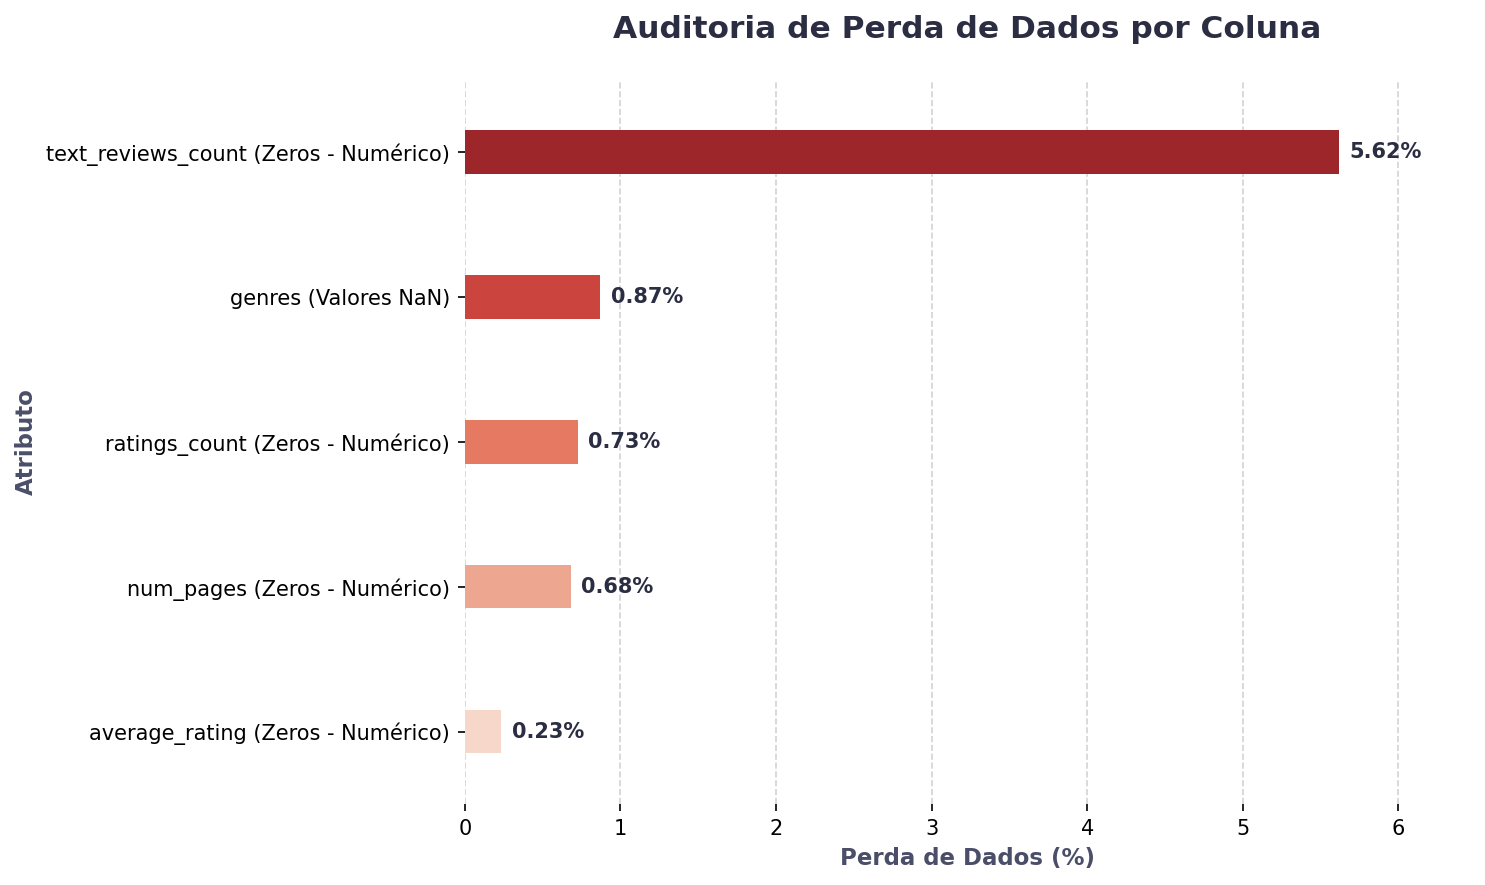

In [189]:
grafico_percentual_missing_data(df=df_resumo_nulos_books, tamanho_figura=(10,6), polegadas=150, width=0.3)

In [149]:
display(
    destacar_anomalias(
        df_books,
        mascara=(df_books['genres'].isnull()),
        colunas_destaque=['genres'],
        colunas_contexto=['Title', 'Author', 'average_rating', 'ratings_count'],
        qtd_linhas=5,
        caption='Livros sem genêro'
    )
)

,Title,Author,average_rating,ratings_count,genres
31,Molly Hatchet - 5 of the Best,Molly Hatchet,4.330000,6,—
201,Timbuktu / Leviathan / Moon Palace,Paul Auster,4.380000,21,—
217,We Were Not Like Other People,Ephraim Sevela/Antonina W. Bouis,4.140000,1,—
265,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0.000000,0,—
306,The 5 Love Languages / The 5 Love Languages Journal,Gary Chapman,4.700000,22,—


In [150]:
# Top Autores entre os nulos
display(
    estilizar_tabela(
        df=df_books[df_books['genres'].isnull()]['Author'].value_counts().to_frame(name='Contagem'),
        qtd_linhas=10,
        caption="Top 10 Autores com mais livros sem gênero"
    )
)

,Contagem
Author,
NOT A BOOK,4
Debra Hess,3
Karen O'Connor/Larry J. Sabato,2
Roger Hargreaves/Gray Jolliffe,2
Mary B. Collins,2
Carl Hiaasen/Edward Asner,2
Molly Hatchet,1
Paul Auster,1
Ephraim Sevela/Antonina W. Bouis,1


In [151]:
display(destacar_anomalias(
    df_books,
    mascara=(df_books['Author'] == 'NOT A BOOK'),
    colunas_destaque=['Author'],
    colunas_contexto=['Title', 'genres'],
    caption="Anomalia: Livros Registrados como 'NOT A BOOK"
))


,Title,genres,Author
1061,Murder by Moonlight & Other Mysteries (New Adventures of Sherlock Holmes 19-24),—,NOT A BOOK
1064,The Unfortunate Tobacconist & Other Mysteries (Sherlock Holmes 1-6),—,NOT A BOOK
5476,The Goon Show Volume 4: My Knees Have Fallen Off!,—,NOT A BOOK
5477,The Goon Show: Moriarty Where Are You?,Humor,NOT A BOOK
5478,The Goon Show Volume 11: He's Fallen in the Water!,—,NOT A BOOK


In [152]:
# Distribuição do Total de Avaliações (ratings_count)
display(
    estilizar_tabela(
        df=df_books[df_books['genres'].isnull()]['ratings_count'].value_counts().to_frame(name='contagem'),
        qtd_linhas=5,
        caption="Contagem de avaliações mais comuns nos nulos"
    )
)

,contagem
ratings_count,
0,16
1,9
5,9
4,8
2,6


In [153]:
# Distribuição das Notas Médias (average_rating)
display(
    estilizar_tabela(
        df=df_books[df_books['genres'].isnull()]['average_rating'].value_counts().to_frame(name='contagem'),
        qtd_linhas=5,
        caption="Notas médias mais comuns nos livros sem gênero"
    )
)

,contagem
average_rating,
4.000000,13
0.000000,11
5.000000,7
3.600000,5
4.500000,4


In [154]:
# Top Editoras entre os nulos
display(
    estilizar_tabela(
        df=df_books[df_books['genres'].isnull()]['publisher'].value_counts().to_frame(name='contagem'),
        qtd_linhas=5,
        caption="Top Editoras com livros sem gênero"
    )
)

,contagem
publisher,
Cliffs Notes,5
Routledge,3
BBC Physical Audio,3
Cavendish Square Publishing,3
Longman Publishing Group,2


In [155]:
#  Amostra das datas de publicação (usando colchetes duplos para retornar DataFrame direto)
display(
    estilizar_tabela(
        df=df_books[df_books['genres'].isnull()][['publication_date']],
        qtd_linhas=10,
        caption="Amostra de datas de publicação (Livros sem gênero)"
    )
)

,publication_date
31,6/10/2003
201,11/7/2002
217,1/1/1989
265,9/1/2001
306,1/1/2005
362,2/10/2006
392,9/1/1998
441,1/30/1989
463,9/13/1965
507,12/29/1983


In [156]:
# Contagem e Porcentagem de Idiomas entre os livros sem gênero
display(
    estilizar_tabela(
        df=df_books[df_books['genres'].isnull()]['language_code'].value_counts().to_frame(name='contagem'),
        qtd_linhas=10,
        caption="Top 10 Idiomas nos livros sem gênero"
    )
)

display(
    estilizar_tabela(
        df=(df_books[df_books['genres'].isnull()]['language_code'].value_counts(normalize=True) * 100).to_frame(name='porcentagem'),
        qtd_linhas=10,
        caption="Porcentagem de cada idioma entre os nulos"
    )
)

,contagem
language_code,
eng,84
en-US,6
spa,2
fre,1
ger,1
srp,1
grc,1
wel,1


,porcentagem
language_code,
eng,86.597938
en-US,6.185567
spa,2.061856
fre,1.030928
ger,1.030928
srp,1.030928
grc,1.030928
wel,1.030928


In [157]:
display(
    estilizar_tabela(
        df=(df_books['language_code'].value_counts() / len(df_books) * 100).to_frame(name='porcentagem'),
        qtd_linhas=10,
        caption="Porcentagem de cada idioma entre os livros"
    )
)

,porcentagem
language_code,
eng,80.084479
en-US,12.662892
spa,1.959198
en-GB,1.923250
fre,1.294149
ger,0.889728
jpn,0.413409
mul,0.170756
zho,0.125820


In [158]:
display(destacar_anomalias(
    df_books,
    mascara=(df_books['average_rating'] == 0),
    colunas_destaque=['average_rating'],
    colunas_contexto=['Title', 'Author', 'ratings_count', 'text_reviews_count'],
    caption="Anomalia: Livros com Avaliação Média Igual a Zero"
))

nota_zero = (df_books['average_rating'] == 0).sum()
print(f"\nTotal de livros com avaliação média igual a zero: {nota_zero}")

,Title,Author,ratings_count,text_reviews_count,average_rating
265,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0,0,0.000000
375,Juiced Official Strategy Guide,Doug Walsh,0,0,0.000000
987,Open City 6: The Only Woman He Ever Left,Open City Magazine/James Purdy/Daniel Pinchbeck/Michael Cunningham/Deborah Garrison/Rem Koolhaas/Rick Moody/Strawberry Saroyan/Debra Garrison,0,0,0.000000
2532,"How To Meditate: An Anthology Of Talks On Meditation And ""Meditation: The Bridge Is Flowing But The River Is Not",Frederick P. Lenz,0,0,0.000000
2533,Insights: Talks On The Nature Of Existence,Frederick P. Lenz,0,0,0.000000
2758,Venac sonetnih venaca; Puževa srma,Dobrica Erić,0,0,0.000000
3493,Brodie's notes on Aldous Huxley's brave new world,Graham Handley,0,0,0.000000
4242,American Film Guide,Frank N. Magill,0,0,0.000000
4678,The Man and the Author: John Milton: Twentieth Century Perspectives,J. Martin Evans,0,0,0.000000
5325,Canopy: A Work for Voice and Light in Harvard Yard,David Ward/Parveen Adams/Seamus Heaney/Ivan Gaskell,0,0,0.000000



Total de livros com avaliação média igual a zero: 26


In [159]:
display(destacar_anomalias(
    df_books,
    mascara=(df_books['ratings_count'] == 0),
    colunas_destaque=['ratings_count'],
    colunas_contexto=['Title', 'Author', 'average_rating', 'text_reviews_count'],
    caption="Anomalia: Livros sem Nenhuma Avaliação"
))

n_nota_zero = (df_books['ratings_count'] == 0).sum()
print(f"\nTotal de livros com 0 avaliações: {n_nota_zero}")

,Title,Author,average_rating,text_reviews_count,ratings_count
264,Lonely Planet Londres,Lonely Planet/Sarah Johnstone/Tom Masters,4.030000,0,0
265,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0.000000,0,0
375,Juiced Official Strategy Guide,Doug Walsh,0.000000,0,0
525,American Government: Continuity and Change Alternate Edition,Karen O'Connor/Larry J. Sabato,2.830000,0,0
526,Essentials of American and Texas Government: Continuity and Change,Karen O'Connor/Larry J. Sabato,3.500000,0,0
624,Comoediae 1: Acharenses/Equites/Nubes/Vespae/Pax/Aves,Aristophanes/F.W. Hall/W.M. Geldart,5.000000,0,0
747,Melville and the politics of identity: From *King Lear* to *Moby-Dick*,Julian Markels,3.330000,0,0
935,April May und June,Elizabeth von Arnim,3.880000,0,0
987,Open City 6: The Only Woman He Ever Left,Open City Magazine/James Purdy/Daniel Pinchbeck/Michael Cunningham/Deborah Garrison/Rem Koolhaas/Rick Moody/Strawberry Saroyan/Debra Garrison,0.000000,0,0
1110,Dr No / Moonraker / Thunderball / From Russia with Love / On Her Majesty's Secret Service / Goldfinger,Ian Fleming,3.980000,0,0



Total de livros com 0 avaliações: 81


In [160]:
display(destacar_anomalias(
    df_books,
    mascara=(df_books['text_reviews_count'] == 0),
    colunas_destaque=['text_reviews_count'],
    colunas_contexto=['Title', 'Author', 'average_rating', 'ratings_count'],
    qtd_linhas=10,
    caption="Anomalia: Livros sem Nenhuma Avaliação"
))


n_reviews_zero = (df_books['text_reviews_count'] == 0).sum()
print(f"\nTotal de livros com 0 avaliações: {n_reviews_zero}")

,Title,Author,average_rating,ratings_count,text_reviews_count
31,Molly Hatchet - 5 of the Best,Molly Hatchet,4.330000,6,0
77,The Power of One: The Solo Play for Playwrights Actors and Directors,Louis E. Catron,3.670000,10,0
80,What to Sell on ebay and Where to Get It: The Definitive Guide to Product Sourcing for eBay and Beyond,Chris Malta/Lisa Suttora,3.620000,24,0
82,eBay: Top 100 Simplified Tips & Tricks,Julia Wilkinson,4.270000,9,0
102,Dalit: The Black Untaouchables of India,V.T. Rajshekar/Y.N. Kly,4.200000,10,0
104,The Evidence-Based Social Work Skills Book,Barry R. Cournoyer,3.400000,10,0
105,"A Wrinkle in Time: A Guide for Using ""A Wrinkle in Time"" in the Classroom",John Carratello/Patty Carratello/Theresa Wright,4.000000,17,0
108,Literature Circle Guide: A Wrinkle in Time,Tara MacCarthy,3.600000,15,0
160,Salmon of Doubt: Hitchhiking the Galaxy One Last Time,Douglas Adams/Christopher Cerf,3.930000,5,0
217,We Were Not Like Other People,Ephraim Sevela/Antonina W. Bouis,4.140000,1,0



Total de livros com 0 avaliações: 625


In [161]:
mask = (
    (df_books['text_reviews_count'] >= 1) &
    (df_books['average_rating'] == 0.00)
)

display(
    destacar_anomalias(
    df_books,
    mascara=mask,
    colunas_destaque=['text_reviews_count'],
    colunas_contexto=['Title', 'Author', 'ratings_count', 'average_rating', 'genres'],
    caption='Anomalia: Reviws exitindo mesmo sem notas médias'
))

,Title,Author,ratings_count,average_rating,genres,text_reviews_count
10142,Day and Night,Better Homes and Gardens,0,0.000000,Juvenile Nonfiction,1


In [162]:
mask = (
    (df_books['average_rating'] == 0) &
    (df_books['ratings_count'] == 0) &
    (df_books['text_reviews_count'] == 0)
)

n_livros_zero = mask.sum()

display(
    destacar_anomalias(
    df_books,
    mascara=mask,
    colunas_destaque=['text_reviews_count', 'ratings_count', 'average_rating' ],
    colunas_contexto=['Title', 'Author', 'genres'],
    caption='Anomalia: Notas Médias Zeradas, Número de Notas Zerado e Número de Reviews Zerado'
))
print(f"\nTotal de livros com avaliação média, contagem de avaliações e contagem de avaliações de texto iguais a zero: {n_livros_zero}")


,Title,Author,genres,text_reviews_count,ratings_count,average_rating
265,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,—,0,0,0.000000
375,Juiced Official Strategy Guide,Doug Walsh,Games;Activities,0,0,0.000000
987,Open City 6: The Only Woman He Ever Left,Open City Magazine/James Purdy/Daniel Pinchbeck/Michael Cunningham/Deborah Garrison/Rem Koolhaas/Rick Moody/Strawberry Saroyan/Debra Garrison,—,0,0,0.000000
2532,"How To Meditate: An Anthology Of Talks On Meditation And ""Meditation: The Bridge Is Flowing But The River Is Not",Frederick P. Lenz,—,0,0,0.000000
2533,Insights: Talks On The Nature Of Existence,Frederick P. Lenz,Spiritual life,0,0,0.000000
2758,Venac sonetnih venaca; Puževa srma,Dobrica Erić,—,0,0,0.000000
3493,Brodie's notes on Aldous Huxley's brave new world,Graham Handley,—,0,0,0.000000
4242,American Film Guide,Frank N. Magill,—,0,0,0.000000
4678,The Man and the Author: John Milton: Twentieth Century Perspectives,J. Martin Evans,Literary Collections,0,0,0.000000
5325,Canopy: A Work for Voice and Light in Harvard Yard,David Ward/Parveen Adams/Seamus Heaney/Ivan Gaskell,Art,0,0,0.000000



Total de livros com avaliação média, contagem de avaliações e contagem de avaliações de texto iguais a zero: 25


In [163]:
display(
    destacar_anomalias(
    df_books,
    mascara=(df_books['ratings_count']==1),
    colunas_destaque=['ratings_count'],
    colunas_contexto=['Title', 'Author', 'average_rating', 'text_reviews_count'],
    caption='Anomalia: Número de Notas Baixíssimo'
))
n_livros_1_avaliacao = (df_books['ratings_count'] == 1).sum()
print(f"\nTotal de livros com exatamente 1 avaliação: {n_livros_1_avaliacao}")

,Title,Author,average_rating,text_reviews_count,ratings_count
217,We Were Not Like Other People,Ephraim Sevela/Antonina W. Bouis,4.140000,0,1
262,The Mini Rough Guide to London,Rob Humphreys/Beth Chaplin/Rebecca Morrill,3.750000,0,1
481,The Suppliant Maidens/The Persians/Seven against Thebes/Prometheus Bound,Aeschylus/E.D.A. Morshead,4.100000,0,1
499,Clouds/Wasps/Birds (Aristophanes 1),Aristophanes/Peter Meineck,3.770000,0,1
754,Theocritus: Select Poems: Select Poems,Theocritus/Kenneth James Dover,3.000000,1,1
786,Willem de Kooning: Late Paintings,Julie Sylvester/David Sylvester,5.000000,0,1
1107,Harriet the Spy Double Agent (Harriet the Spy Adventures),Maya Gold,3.800000,0,1
1355,Ocean Star Express,Mark Haddon/Peter Sutton,3.570000,0,1
1375,Latitude and Longitude (Rookie Read-About Geography),Rebecca Aberg/Jeanne Clidas,3.530000,0,1
1713,Sparrow Hawk Red,Ben Mikaelsen,3.790000,0,1



Total de livros com exatamente 1 avaliação: 76


In [164]:
mask = (
    (df_books['ratings_count'] == 1) &
    (df_books['average_rating'] == 0.00)
)

display(
    destacar_anomalias(
    df_books,
    mascara=mask,
    colunas_destaque=['text_reviews_count', 'ratings_count', 'average_rating' ],
    colunas_contexto=['Title', 'Author', 'genres'],
    caption='Anomalia: Notas Médias Zeradas, Número de Notas Zerado e Número de Reviews Zerado'
))

,Title,Author,genres,text_reviews_count,ratings_count,average_rating


In [165]:
# Criando uma máscara booleana composta para agrupar todas as anomalias de dados identificadas
condicao_lixo = (
    (df_books['genres'].isnull()) | # Regra 1: Obras sem categorização literária
    (df_books['average_rating'] == 0.0) | # Regra 2: Notas zeradas (impossível organicamente na plataforma)
    ((df_books['average_rating'] > 0.0) & (df_books['ratings_count'] == 0)) # Regra 3: Notas fantasmas sem avaliadores
)

# Simulando o impacto da exclusão antes de aplicar o corte real (Auditoria)
total_remover = condicao_lixo.sum()
print(f"\nTotal de livros que seriam removidos com base na condição de lixo: {total_remover}")

por_remover = (total_remover / len(df_books)) * 100
print(f"Porcentagem de livros que seriam removidos: {por_remover:.2f}%")

# Inspecionando visualmente uma amostra dos dados corrompidos
display(
    destacar_anomalias(
    df_books,
    mascara=condicao_lixo,
    colunas_destaque=['genres', 'ratings_count', 'average_rating' ],
    colunas_contexto=['Title', 'Author', 'text_reviews_count'],
    qtd_linhas=10,
    caption='Anomalia: Notas Médias Zeradas, Número de Notas Zerado e Número de Reviews Zerado'
))


Total de livros que seriam removidos com base na condição de lixo: 162
Porcentagem de livros que seriam removidos: 1.46%


,Title,Author,text_reviews_count,genres,ratings_count,average_rating
31,Molly Hatchet - 5 of the Best,Molly Hatchet,0,—,6,4.330000
201,Timbuktu / Leviathan / Moon Palace,Paul Auster,1,—,21,4.380000
217,We Were Not Like Other People,Ephraim Sevela/Antonina W. Bouis,0,—,1,4.140000
264,Lonely Planet Londres,Lonely Planet/Sarah Johnstone/Tom Masters,0,"Travel;Nonfiction;Reference;European Literature,British Literature;History;Reference,Guidebook",0,4.030000
265,Out to Eat London 2002 (Lonely Planet Out to Eat),Lonely Planet/Mark Honan,0,—,0,0.000000
306,The 5 Love Languages / The 5 Love Languages Journal,Gary Chapman,4,—,22,4.700000
362,A Million Little Pieces of Feces,Python Bonkers,6,—,43,3.560000
375,Juiced Official Strategy Guide,Doug Walsh,0,Games;Activities,0,0.000000
392,Gorgias/Phaedrus (Agora),Plato/James H. Nichols Jr.,1,—,18,4.350000
441,Thucydides Book 6 Commentary,Cynthia W. Shelmerdine,0,—,2,4.500000


In [166]:
# Consolidando a limpeza em um DataFrame temporário validado
# Remoção cirúrgica dos nulos apenas na coluna de gêneros
df_clean = df_books.dropna(subset=['genres'])

# Aplicação do filtro de engajamento real utilizando a sintaxe otimizada .query()
df_clean = df_clean.query("average_rating > 0.0 and ratings_count > 0")

print(f"Limpeza concluída! Novo tamanho do dataset: {len(df_clean)}")

Limpeza concluída! Novo tamanho do dataset: 10965


In [167]:
obras_para_testar = 'Breakfast of Champions|Moon Palace|Leviathan|Before Night Falls'

# Filtra as obras específicas
teste = df_clean[df_clean['Title'].str.contains(obras_para_testar, case=False, na=False)]

display(estilizar_tabela(
    df=teste, 
    colunas_selecionadas=['Title', 'ratings_count', 'genres'], 
    caption="Auditoria de QA: Validação de Nulos, Votos e Gêneros em Obras Específicas"
))

,Title,ratings_count,genres
196,Moon Palace,16099,"Fiction;Literature,American;Contemporary;Novels;Literature;The United States Of America;Classics;Literature,20th Century;Roman;Academic,School"
199,Leviathan,11744,"Fiction;Literature,American;Novels;Literature;Contemporary;The United States Of America;Literary Fiction;Mystery;Literature,20th Century;Roman"
2619,Cat's Cradle/God Bless You Mr. Rosewater/Breakfast of Champions,914,Fiction;Science Fiction;Classics
4619,Leviathan,500,"Philosophy;Politics;Classics;Nonfiction;History;Politics,Political Science;Academic,School;Law;Literature,17th Century;Academic"
4620,The Book of Leviathan,631,"Sequential Art,Comics;Sequential Art,Graphic Novels;Fiction;Art;Humor;Fantasy;Comics,Comic Book;Philosophy;Humor,Comedy;Graphic Novels Comics"
8778,Before Night Falls,3158,"Nonfiction;Autobiography,Memoir;LGBT;Biography;LGBT,Queer;History;Biography,Autobiography;LGBT,Gay;Biography Memoir;European Literature,Spanish Literature"


## Conclusão da Análise de Dados Nulos e Anomalias
A análise exploratória identificou inconsistências que podem comprometer a integridade estatística do projeto. A seguir, detalhamos as observações e o tratamento aplicado:

### Observações Identificadas:

- Gêneros Faltantes: A coluna genres apresenta 97 valores nulos. Essa ausência representa apenas 0,87% do dataset e não demonstrou nenhum padrão sistêmico relevante.

- Falta de Engajamento Real (Média 0.00): Foram identificados 26 livros com average_rating igual a 0.00. Todos possuem zero avaliações numéricas (com exceção de um único registro que apresenta apenas uma resenha em texto). Manter esses registros abaixaria a nota média geral e dos nichos de forma distorcida e injusta.

- Avaliações Fantasmas (Inconsistência da Plataforma): Existem 81 livros que exibem uma nota média maior que zero, mas possuem ratings_count igual a 0. Trata-se de dados sujos ou artefatos da plataforma, já que é impossível ter uma média sem avaliadores.

### Decisão e Tratamento:
Para garantir a confiabilidade das métricas de engajamento, optou-se pela remoção total desses registros.

Foram descartados os livros sem gênero, os com nota 0.00 e aqueles com avaliações fantasmas. No total, 162 linhas foram removidas, o que equivale a apenas 1,45% do volume original. Por ser uma perda muito inferior à margem aceitável de 5%, a exclusão não impacta significativamente a representatividade da amostra, resultando em um dataset final altamente íntegro e confiável para as próximas etapas.

- - -

## Validação Visual (Distribuição de Dados)

Após a etapa de higienização, utilizamos visualizações para entender o comportamento das métricas no nosso "Dado Ouro".

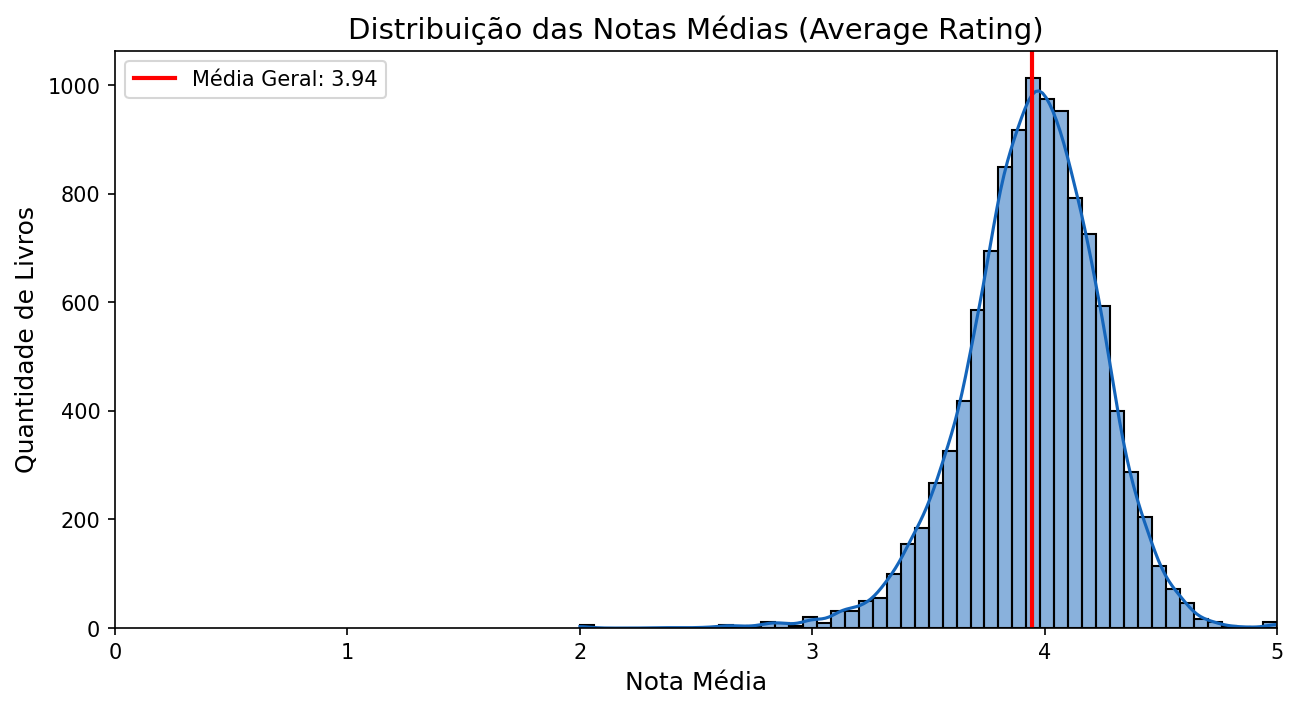

In [168]:
# Visualização da distribuição das notas médias (average_rating) após a limpeza dos dados
plt.figure(figsize=(10, 5), dpi=150)

sns.histplot(df_clean['average_rating'], bins=50, kde=True, color='#1465bb')
plt.xlim(0, 5)
plt.xticks([0, 1, 2, 3, 4, 5])
plt.title('Distribuição das Notas Médias (Average Rating)', fontsize=14)
plt.xlabel('Nota Média', fontsize=12)
plt.ylabel('Quantidade de Livros', fontsize=12)

media_geral = df_clean['average_rating'].mean()
plt.axvline(
    media_geral,
    color='#ff0000',
    linestyle='-', 
    linewidth=2,
    label=f'Média Geral: {media_geral:.2f}'
)
plt.legend()

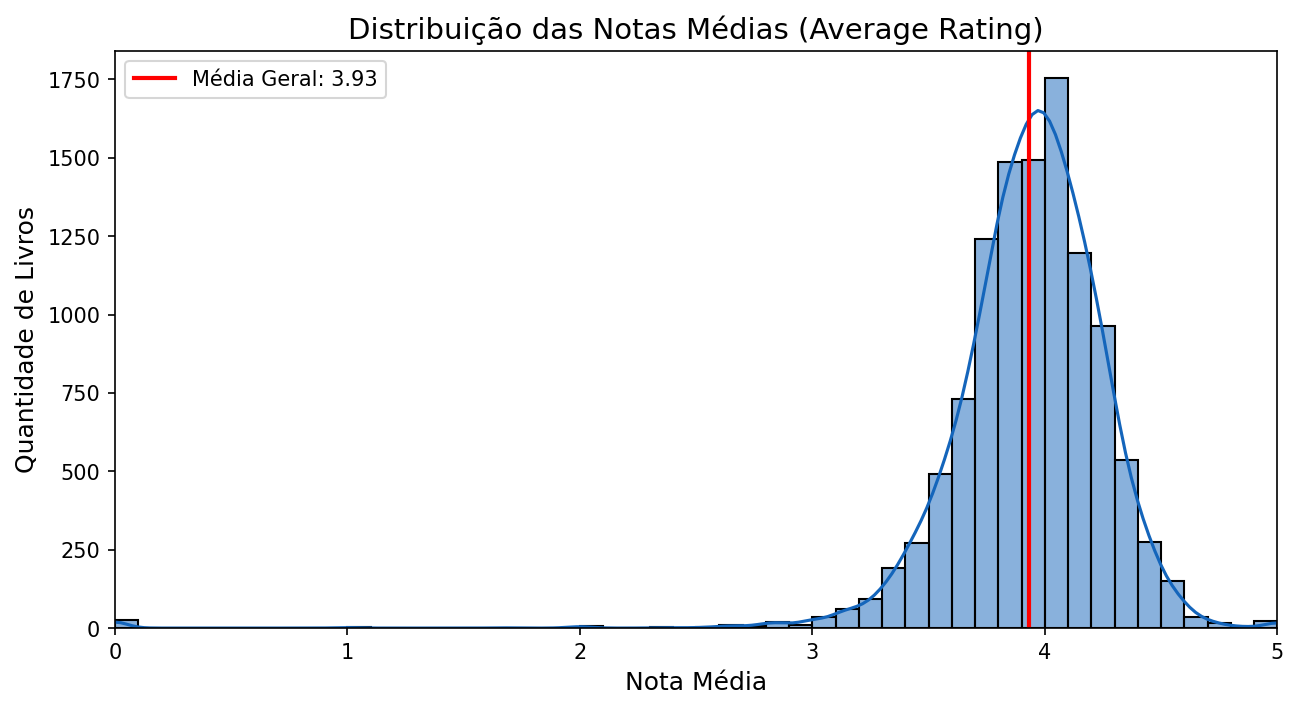

In [169]:
# Visualização da distribuição das notas médias (average_rating) antes da limpeza dos dados

plt.figure(figsize=(10, 5), dpi=150)

sns.histplot(df_books['average_rating'], bins=50, kde=True, color='#1465bb')
plt.xlim(0, 5)
plt.xticks([0, 1, 2, 3, 4, 5])
plt.title('Distribuição das Notas Médias (Average Rating)', fontsize=14)
plt.xlabel('Nota Média', fontsize=12)
plt.ylabel('Quantidade de Livros', fontsize=12)

media_geral = df_books['average_rating'].mean()
plt.axvline(
    media_geral,
    color='#ff0000',
    linestyle='-', 
    linewidth=2,
    label=f'Média Geral: {media_geral:.2f}'
)
plt.legend()

Text(0, 0.5, 'Quantidade de Livros')

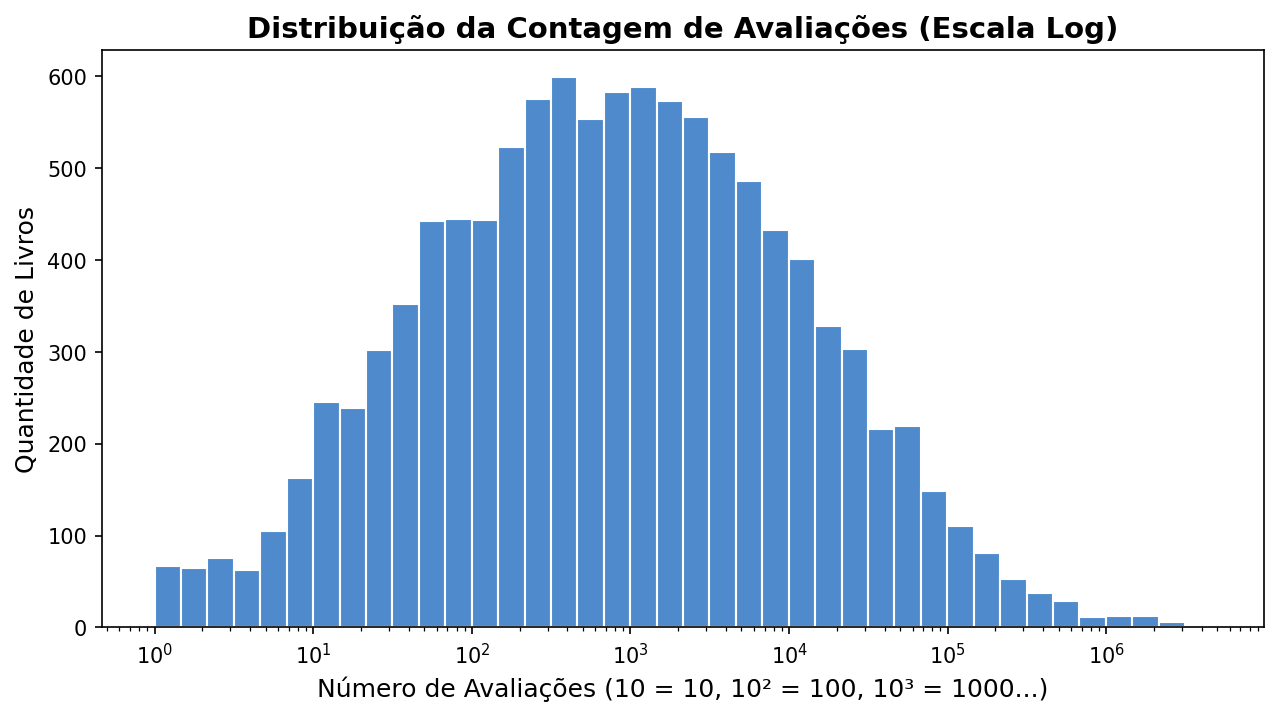

In [170]:
plt.figure(figsize=(10, 5), dpi=150)

sns.histplot(
    data=df_clean, 
    x='ratings_count', 
    color='#1465bb', 
    log_scale=True, 
    bins=40,
    edgecolor='white'
)

plt.title('Distribuição da Contagem de Avaliações (Escala Log)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Avaliações (10 = 10, 10² = 100, 10³ = 1000...)', fontsize=12)
plt.ylabel('Quantidade de Livros', fontsize=12)

In [171]:
display(estilizar_tabela(
    df=df_clean['isbn'].to_frame(),
    qtd_linhas=10
))

,isbn
0,0439785960
1,0439358078
2,0439554896
3,043965548X
4,0439682584
5,0976540606
6,0439827604
7,0517226952
8,0345453743
9,1400052920


In [172]:
display(estilizar_tabela(
    df_clean['isbn13'].to_frame(),
    qtd_linhas=10
))

,isbn13
0,9780439785969
1,9780439358071
2,9780439554893
3,9780439655484
4,9780439682589
5,9780976540601
6,9780439827607
7,9780517226957
8,9780345453747
9,9781400052929


In [173]:
# Extraindo o top 10 idiomas mais comuns para avaliar o potencial de segmentação regional

display(estilizar_tabela(
    df=df_clean['language_code'].value_counts().to_frame(name='Contagem'), 
    qtd_linhas=10,
    caption="Recorrência de cada idioma entre os livros:"
))

# Convertendo a contagem absoluta em porcentagem para entender a distribuição global do dataset
per = (
    df_clean['language_code'].value_counts() /
    len(df_clean) * 100
)
display(estilizar_tabela(
    df=per.to_frame(name='Porcentagem'),
    qtd_linhas=10,
    caption="Porcentagem de cada idioma entre os livros:"
))

,Contagem
language_code,
eng,8778
en-US,1403
en-GB,214
spa,210
fre,139
ger,95
jpn,45
mul,19
zho,14


,Porcentagem
language_code,
eng,80.054720
en-US,12.795258
en-GB,1.951664
spa,1.915185
fre,1.267670
ger,0.866393
jpn,0.410397
mul,0.173279
zho,0.127679


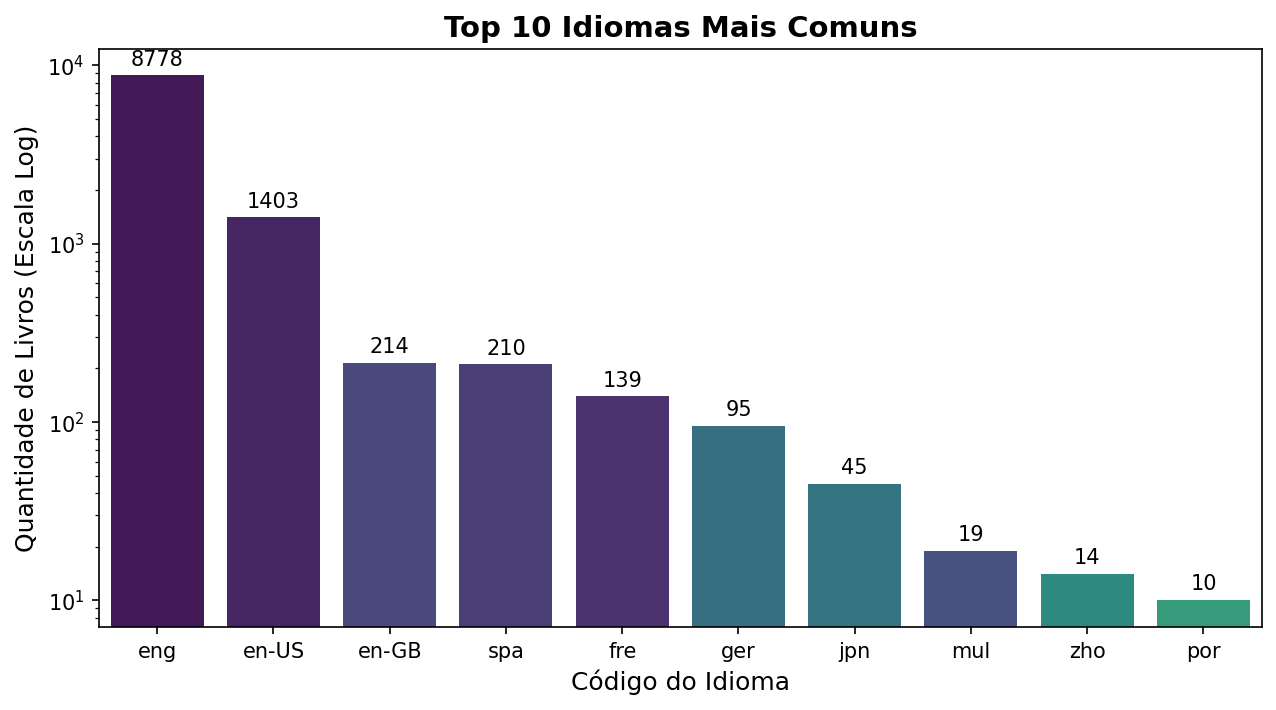

In [174]:
plt.figure(figsize=(10, 5), dpi=150)

ax = sns.countplot(
    x='language_code', 
    data=df_clean,
    order=df_clean['language_code'].value_counts().head(10).index, 
    hue='language_code', 
    palette='viridis',
    legend=False 
)

plt.title('Top 10 Idiomas Mais Comuns', fontsize=14, fontweight='bold')
plt.xlabel('Código do Idioma', fontsize=12)

plt.ylabel('Quantidade de Livros (Escala Log)', fontsize=12) 

# Transformando o eixo Y em escala logarítmica
plt.yscale('log')

# Adicionando os valores numéricos no topo de cada barra
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

(0.0, 92.06292749658003)

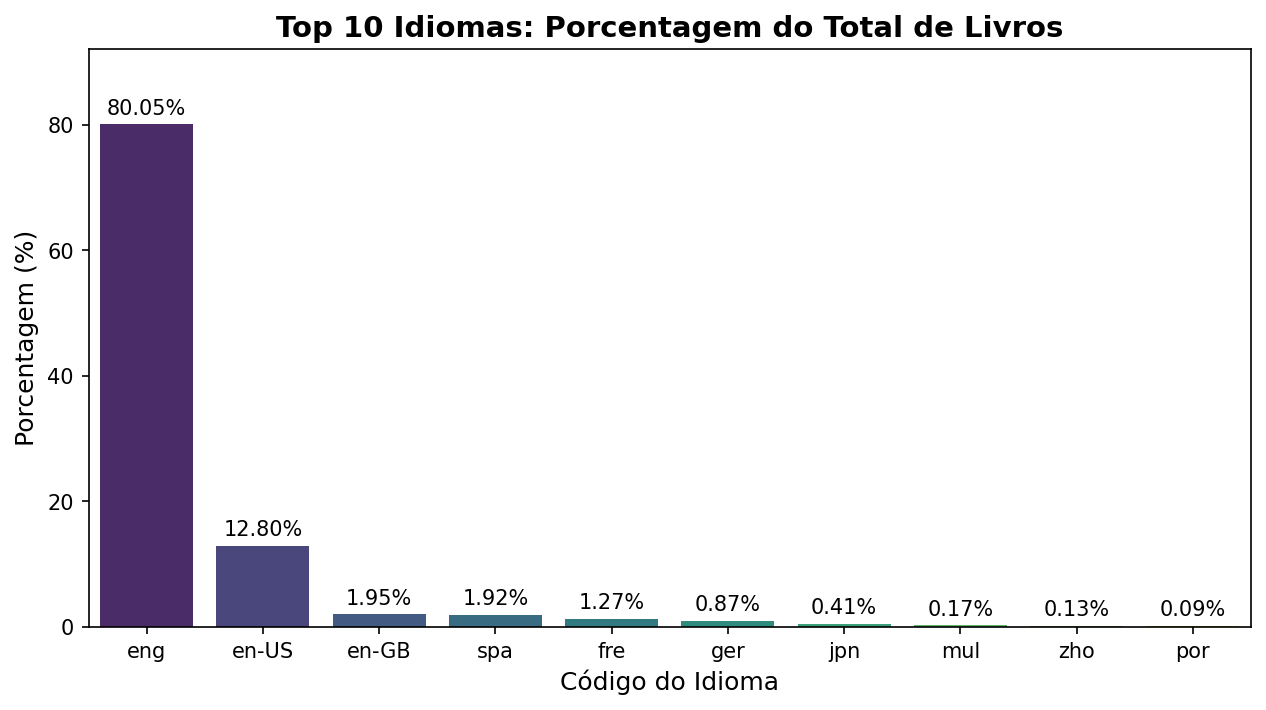

In [175]:
plt.figure(figsize=(10, 5), dpi=150)

# Pegando apenas os 10 primeiros para não poluir o gráfico
top_10_per = per.head(10)

ax = sns.barplot(
    x=top_10_per.index,
    y=top_10_per.values,
    hue=top_10_per.index,
    palette='viridis',
    legend=False
)

# olocando a porcentagem exata em cima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3, fontsize=10)

plt.title('Top 10 Idiomas: Porcentagem do Total de Livros', fontsize=14, fontweight='bold')
plt.xlabel('Código do Idioma', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)

# Aumentamos o teto do eixo Y em 15% para o texto da maior barra não cortar
plt.ylim(0, top_10_per.max() * 1.15) 


## Avaliação de Identificadores Alternativos e Regionalização
O dataset possui colunas voltadas para a identificação comercial e categorização demográfica das obras. Para otimizar a estrutura final, foi realizada uma análise de necessidade e sobreposição dessas variáveis.

### Observações Identificadas:

- Identificadores Redundantes: As colunas isbn e isbn13 representam o International Standard Book Number. Ambas atuam como chaves alternativas de identificação única para a mesma obra. O isbn13 é essencialmente uma extensão do padrão original, gerando uma redundância de dados diretos no dataset.

- Potencial Analítico de Idioma: A variável categórica language_code (idioma original do livro) apresenta uma rica diversidade de registros. Esta dimensão tem alto valor estratégico, pois será o pilar para futuras análises de regionalização, permitindo segmentar o comportamento e a popularidade dos tropos literários por mercado linguístico.

- Distribuição Orgânica das Notas (average_rating): A plotagem do histograma serviu como prova visual da eficácia da limpeza de dados. A distribuição resultante apresenta uma assimetria negativa (Left-Skewed), com a vasta maioria do engajamento orgânico concentrada na faixa de 3.5 a 4.2. Avaliações perfeitas (5.0) ou muito baixas (menores que 2.0) mostraram-se estatisticamente raras na plataforma.

- Engajamento de Cauda Longa (ratings_count): A análise de popularidade demonstrou um comportamento clássico de Cauda Longa. Foi necessário o uso de uma escala logarítmica para contornar a distorção visual gerada por um grupo ínfimo de best-sellers globais, revelando que a grande maioria do acervo literário concentra-se na faixa de nicho (entre 100 e 10.000 avaliações).

### Decisão e Tratamento:
Aplicando o princípio de redução de dimensionalidade e eficiência de armazenamento, a coluna isbn13 será excluída (dropada), eliminando a redundância. A coluna isbn tradicional será mantida como o identificador comercial padrão caso sejam necessários cruzamentos futuros (como agregações com datasets de livrarias externas). A coluna language_code será integralmente preservada para viabilizar os filtros demográficos no Dashboard.

Por fim, os gráficos de validação visual gerados nesta etapa (histogramas de distribuição em escala linear e logarítmica, e barras de proporção) serão mantidos no notebook como documentação formal da EDA (Exploratory Data Analysis), servindo de garantia técnica da higienização dos dados antes da carga no banco de dados SQLite.

---

## Exploração de Outliers e Anomalias Numéricas

Nesta etapa, o objetivo é auditar a base de dados em busca de duas frentes: **falhas de integridade física** (erros do sistema) e **anomalias orgânicas** (comportamento atípico, porém real, de leitores e obras).

In [176]:
# Verifica quais valores são menores que zero (< 0)

display(estilizar_tabela(
    df=(df_clean.select_dtypes(include='number') < 0)
        .sum()
        .to_frame(name='Valores Negativos'
    ),
    caption="Quantidade de valores impossíveis (negativos) por coluna:"
))

,Valores Negativos
Book Id,0
average_rating,0
isbn13,0
num_pages,0
ratings_count,0
text_reviews_count,0


In [177]:
display(estilizar_tabela(
    df=df_clean.select_dtypes(include='number')
        .corr()['ratings_count']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
    caption="Correlação com a Coluna 'ratings_count'"
))

,Correlação
ratings_count,1.000000
text_reviews_count,0.865929
average_rating,0.041397
num_pages,0.033537
isbn13,0.004998
Book Id,-0.077133


(0.0, 304324.1600000041)

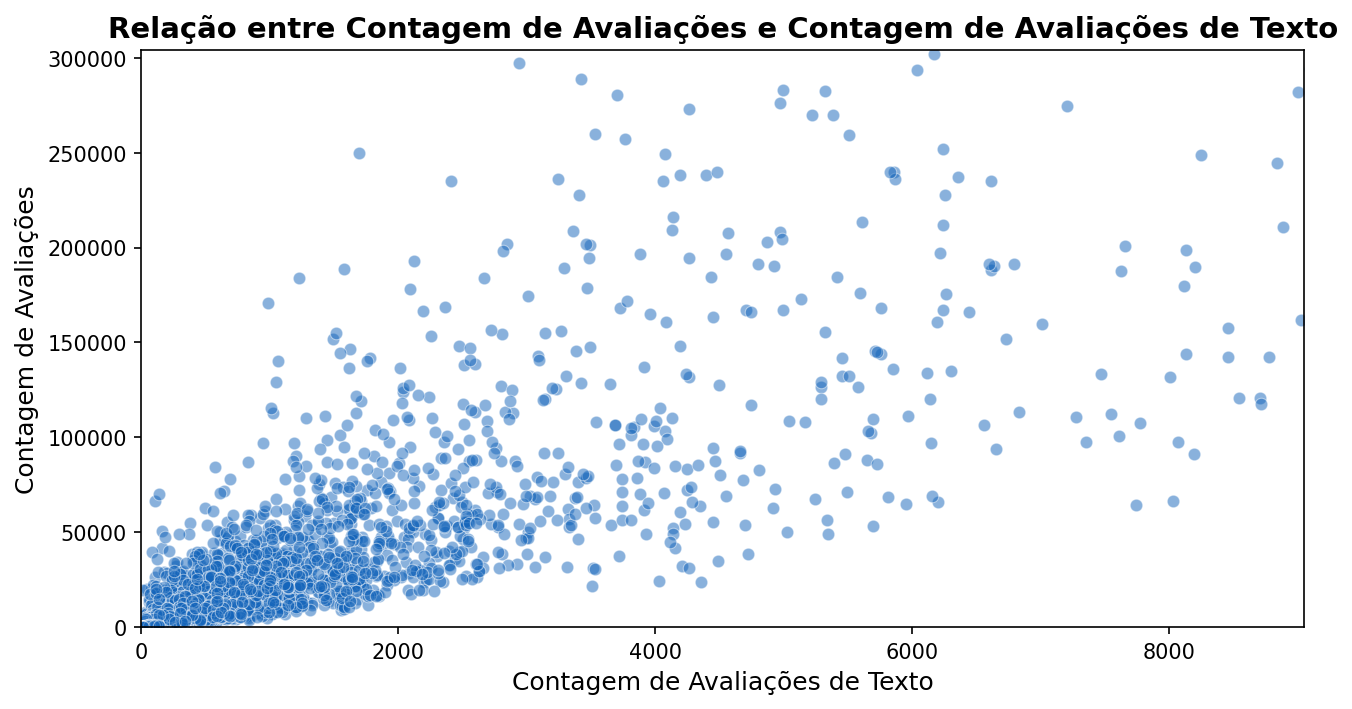

In [178]:
plt.figure(figsize=(10, 5), dpi=150)
sns.scatterplot(
    data=df_clean,
    x='text_reviews_count',
    y='ratings_count',
    alpha=0.5,
    color='#1465bb'
)
plt.title('Relação entre Contagem de Avaliações e Contagem de Avaliações de Texto', fontsize=14, fontweight='bold')
plt.xlabel('Contagem de Avaliações de Texto', fontsize=12)
plt.ylabel('Contagem de Avaliações', fontsize=12)

plt.xlim(0, df_clean['text_reviews_count'].quantile(0.99))
plt.ylim(0, df_clean['ratings_count'].quantile(0.99))

In [179]:
display(estilizar_tabela(
    df=df_clean
        .select_dtypes(include='number')
        .corr()['average_rating']
        .sort_values(ascending=False)
        .to_frame(name='Correlação'),
    caption="Correlação com a coluna 'average_count"
))

,Correlação
average_rating,1.000000
num_pages,0.172264
ratings_count,0.041397
text_reviews_count,0.034173
isbn13,-0.011123
Book Id,-0.038800


(0.0, 6.0)

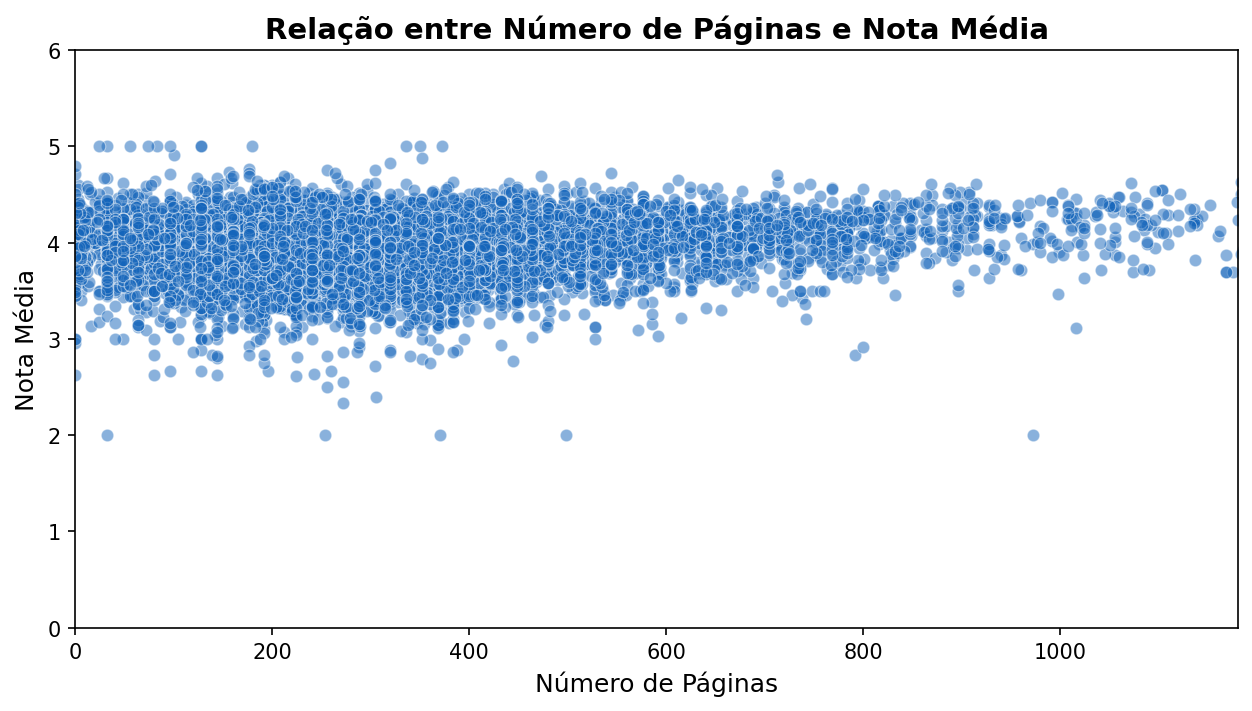

In [180]:
plt.figure(figsize=(10, 5), dpi=150)

sns.scatterplot(
    data=df_clean,
    x='num_pages',
    y='average_rating',
    alpha=0.5,
    color='#1465bb'
)

plt.title('Relação entre Número de Páginas e Nota Média', fontsize=14, fontweight='bold')
plt.xlabel('Número de Páginas', fontsize=12)
plt.ylabel('Nota Média', fontsize=12)

plt.xlim(0, df_clean['num_pages'].quantile(0.99))
plt.ylim(0, 6)

(0.0, 6.0)

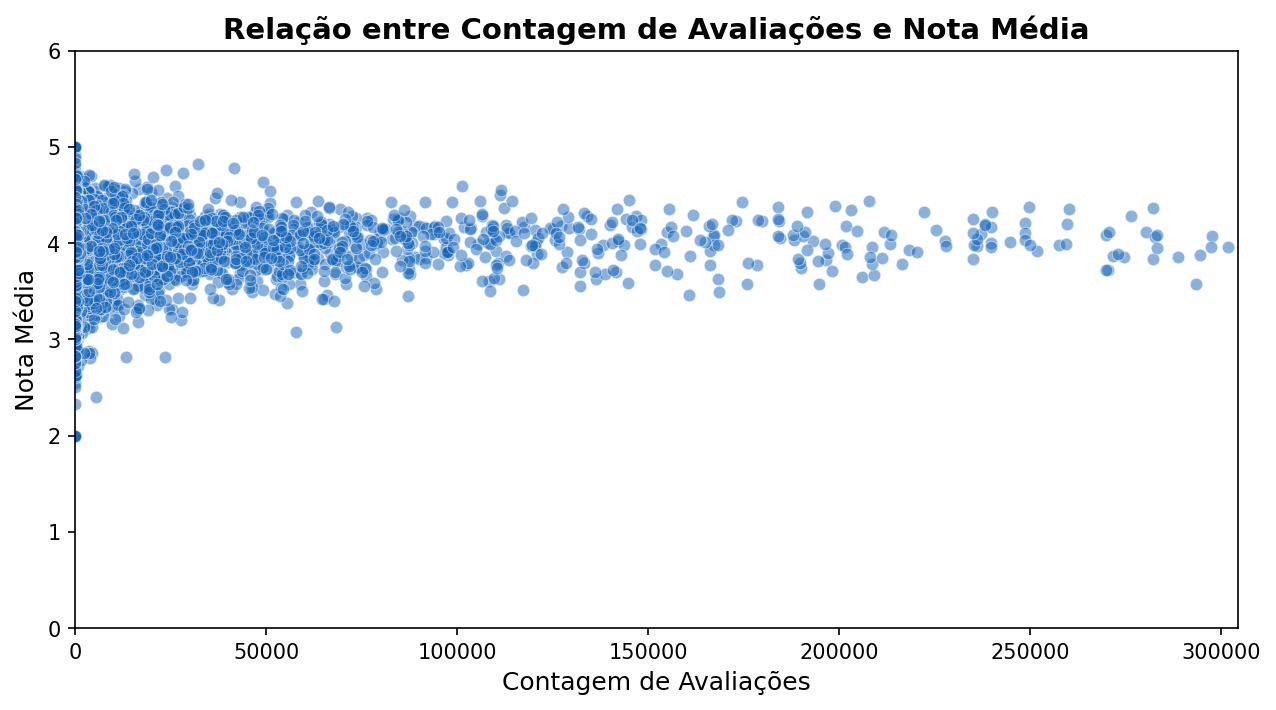

In [181]:
plt.figure(figsize=(10, 5), dpi=150)

sns.scatterplot(
    data=df_clean,
    x='ratings_count',
    y='average_rating',
    alpha=0.5,
    color='#1465bb'
)
plt.title('Relação entre Contagem de Avaliações e Nota Média', fontsize=14, fontweight='bold')
plt.xlabel('Contagem de Avaliações', fontsize=12)
plt.ylabel('Nota Média', fontsize=12)

plt.xlim(0, df_clean['ratings_count'].quantile(0.99))
plt.ylim(0, 6)


In [182]:
# Verificando a distribuição dos livros com pouquíssimos votos

display(estilizar_tabela(
    df=df_clean[df_clean['ratings_count'] <= 10]['ratings_count']
        .value_counts()
        .sort_index()
        .to_frame(name='Contagem'),
    caption="Quantidade de livros por número de votos (de 0 a 10):"
))

# Verificando especificamente quem tem apenas 1 voto
apenas_um = (df_clean['ratings_count'] == 1).sum()
print(f"\nLivros que possuem exatamente 1 voto: {apenas_um}")

,Contagem
ratings_count,
1,67
2,65
3,76
4,63
5,52
6,53
7,54
8,54
9,55



Livros que possuem exatamente 1 voto: 67


In [183]:
print(f"Total de livros com pouquíssimos votos: {
    df_clean[df_clean['ratings_count'] <= 10]['ratings_count']
        .values
        .sum()
}")

Total de livros com pouquíssimos votos: 3100


In [184]:
media = df_clean[df_clean['ratings_count'] <= 10]['average_rating'].mean()

print(f"Média das notas dos livros com pouquíssimos votos (<= 10): {media:.2f}")

Média das notas dos livros com pouquíssimos votos (<= 10): 3.88


In [185]:
media = df_clean[df_clean['ratings_count'] == 1]['average_rating'].mean()

print(f"Média das notas dos livros com apenas 1 voto: {media:.2f}")

Média das notas dos livros com apenas 1 voto: 3.78


### Observações Identificadas:

- Teste de Integridade Física (*Sanity Check*)

  - Antes de analisar distribuições, precisamos garantir que as variáveis numéricas respeitam os limites da realidade. Valores de páginas, quantidade de avaliações e notas não podem ser negativos. O objetivo aqui não é encontrar "livros ruins", mas detectar **corrompimento de dados na origem** — registros onde o próprio sistema de coleta falhou e gerou valores fisicamente impossíveis.

- Análise de Outliers Orgânicos

  - Com a base fisicamente íntegra, investigamos pontos fora da curva no **comportamento de engajamento da plataforma**. Diferente das anomalias físicas, outliers orgânicos são valores reais, mas estatisticamente extremos — eles existem porque o mundo é assim, não porque houve um erro.

  - Para identificá-los, analisamos visualmente as correlações entre as principais features numéricas por meio de *scatterplots*, técnica que permite enxergar tanto a tendência geral de uma relação quanto os pontos que fogem dela.

- Distribuição de Engajamento Mínimo

  - Após confirmar a ausência de erros físicos e compreender a natureza dos outliers orgânicos, foi realizado um terceiro diagnóstico: a análise do **limite inferior de engajamento estatístico**. A questão central aqui não é se o dado é real, mas se ele é *representativo o suficiente* para sustentar uma análise comparativa.

  - A análise de integridade revelou que não há registros com zero avaliações no dataset processado. Identificamos **67 obras com apenas 1 voto** (média de $3.78$) e **593 com menos de 10 votos** (média de $3.88$).

### Decisão e Tratamento:
  - O teste vetorial confirmou a ausência de valores negativos nas colunas numéricas, atestando a **integridade basal da extração**. O dataset passou por este crivo sem nenhuma violação lógica de domínio.

  -  Os pontos extremos identificados nos gráficos não representam erros sistêmicos, mas sim o fenômeno de **Cauda Longa literária** (*Long Tail*) — a coexistência de obras de altíssimo nicho com poucas resenhas e best-sellers globais com centenas de milhares de avaliações. Este é um comportamento esperado e genuíno de plataformas de conteúdo em larga escala. **Estes registros serão mantidos, pois refletem a realidade da plataforma.**
  
---

## Resumo Final Para Limpeza e Preparação

* **Estado Inicial:** O dataset bruto iniciou o processo com 12 colunas e 11.127 linhas.
* **Redução de Dimensionalidade:** A coluna `isbn13` será removida por ser estruturalmente redundante, mantendo-se apenas o identificador `isbn` principal.
* **Uniformização de Colunas** A coluna `Title` será editada para `title` para padronizala com os demais datasets. O mesmo ocorrerá com a coluna `Book Id` que se tornará `book_id`.
* **Tratamento de Nulos e Anomalias Numéricas:**
  * Os registros com valores ausentes na coluna `genres` serão descartados.
  * Obras com inconsistência de engajamento (notas `0.00` ou `ratings_count` zerado) serão removidas para não distorcer as médias estatísticas do projeto.
  * *Impacto do corte:* Apenas 162 linhas removidas (1,45% de perda, volume estatisticamente irrelevante).
* **Integridade Física Confirmada:** O teste vetorial sobre todas as colunas numéricas confirmou a ausência de valores negativos, validando que o pipeline de extração não gerou corrompimento de dados na origem.
* **Outliers Orgânicos Mantidos:** Os pontos extremos de engajamento identificados nos scatterplots (como best-sellers globais) refletem a realidade da plataforma e o fenômeno de Cauda Longa literária. Nenhuma remoção foi aplicada sobre eles.
* **Engajamento Mínimo:** 593 obras com menos de 10 avaliações foram sinalizadas como `"Baixa Relevância Estatística"`. Esses registros serão preservados no dataset exploratório, mas um *threshold* de corte será aplicado nas etapas de análise correlacional para garantir que o `average_rating` represente uma opinião coletiva e não individual.
* **Engenharia de Features (Refatoração):** A coluna de texto bruto `genres` será processada, fatiada e "explodida" em formato de lista, atomizando os dados para suportar a arquitetura de banco de dados relacional.
* **Estado Final Esperado (Dado Ouro):** O dataset purificado resultará em um DataFrame final e íntegro de **10.965 linhas**, pronto para ser injetado nas tabelas do banco de dados SQLite (`tropes_literarios.db`).